# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [2]:
import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [3]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    all_sess_no_drop[sess] = td

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


In [5]:
perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
td_drop = dsp.drop_trials_sem_crosses_zero(perturb_td_shuff, std=False)
td_drop.loc[:, 'power'] = td_drop.apply(
        lambda row: row['power'][row["concat_perturb_time"] - 200:row["concat_perturb_time"] + 301, :],
        axis=1
    )

/tmp/ipykernel_3560683/3062433816.py:1: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


  drop_trials_sem_crosses_zero: by SEM: 292  |  by value: 423  |  kept: 291/424 (68.6%)


In [100]:
pc_dict = {
    "MOp": 30,
    "SSp": 25,
    "CP": 30,
    "VAL": 40,
}
td_potent_null = perturb_td_shuff.copy()
for area_a in Params.areas:
    for area_b in Params.areas:
        if area_b == area_a:
            continue
        td_potent_null = subspaces.compute_potent_null_td(
            td_=td_potent_null,
            signal_x=f'{area_a}_rates_pca',
            signal_y=f'{area_b}_rates_pca',
            origin_rank=pc_dict[area_a],
            target_rank=pc_dict[area_a],
            n_iter=2,
            window=(200, 400)
        )

Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.2719. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0607
	Iter: 2. Prediction R2 = 0.0032
Iteration number: 2. R2 below 0, breaking
	Final Prediction R2 = 0.0032
Diagnostics:
	Total MOp_rates_pca var:         12480.15
	Fraction Potent (dim: 10) var:    0.337
	Fraction Null (dim: 10) var:      0.138
	Fraction Null init var:          0.288
	Fraction MOp_rates_pca var:      0.625
Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = 0.2841. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0546
	Iter: 2. Prediction R2 = 0.0054
Iteration number: 2. R2 below 0, breaking
	Final Prediction R2 = 0.0054
Diagnostics:
	Total MOp_rates_pca var:         12480.15
	Fraction Potent (dim: 10) var:    0.207
	Fraction Null (dim: 10) var:      0.183
	Fraction Null init var:          0.418
	Fraction MOp_rates_pca var:      0.625
Computing MOp_rates_pca -> VA

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, KFold

shuffle = False
alpha = 0.01

td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=True)

td_potent_null_ord = (
    td_potent_null_dropped
    .sort_values(by="trial_id")
    .reset_index(drop=True)
)

area_pairs = [(a, b) for a in Params.areas for b in Params.areas if a != b]

results = []

def variance_match(a, b):
    """Scale both arrays down to the variance of whichever has less."""
    var_a = np.var(a)
    var_b = np.var(b)
    var_min = min(var_a, var_b)
    return a * np.sqrt(var_min / var_a), b * np.sqrt(var_min / var_b)

for area_x, area_y in area_pairs:
    origin_rank = 40
    window = (200, 250)

    full_arr = np.stack(td_potent_null_ord[f"{area_x}_rates_pca"].values)[:, window[0]:window[1], :origin_rank]
    full_arr = full_arr.mean(1)

    potent_arr = np.stack(td_potent_null_ord[f"{area_x}_rates_pca_potent_{area_y}_rates_pca"].values)[:, window[0]:window[1], :]
    potent_arr = potent_arr.mean(1)

    null_arr = np.stack(td_potent_null_ord[f"{area_x}_rates_pca_null_{area_y}_rates_pca"].values)[:, window[0]:window[1], :]
    null_arr = null_arr.mean(1)

    potent_arr, null_arr = variance_match(potent_arr, null_arr)

    rng = np.random.default_rng(seed=42)
    perm = rng.permutation(td_potent_null_ord.disturb_sum.values.shape[0])

    y_dist = td_potent_null_ord.disturb_sum.values
    r2s_full        = cross_val_score(Ridge(alpha), full_arr,   y_dist,        scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
    r2s_potent      = cross_val_score(Ridge(alpha), potent_arr, y_dist,        scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
    r2s_null        = cross_val_score(Ridge(alpha), null_arr,   y_dist,        scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
    r2s_lower_bound = cross_val_score(Ridge(alpha), potent_arr, y_dist[perm],  scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))

    print(f"[{area_x} -> {area_y}] Disturbance -- full: {r2s_full.mean():.4f}  potent: {r2s_potent.mean():.4f}  null: {r2s_null.mean():.4f}  lb: {r2s_lower_bound.mean():.4f}")

    window = (200, 300)

    full_arr = np.stack(td_potent_null_ord[f"{area_x}_rates_pca"].values)[:, window[0]:window[1], :]
    full_arr = full_arr.reshape(full_arr.shape[0], -1)

    potent_arr = np.stack(td_potent_null_ord[f"{area_x}_rates_pca_potent_{area_y}_rates_pca"].values)[:, window[0]:window[1], :]
    potent_arr = potent_arr.reshape(potent_arr.shape[0], -1)

    null_arr = np.stack(td_potent_null_ord[f"{area_x}_rates_pca_null_{area_y}_rates_pca"].values)[:, window[0]:window[1], :17]
    null_arr = null_arr.reshape(null_arr.shape[0], -1)

    potent_arr, null_arr = variance_match(potent_arr, null_arr)

    rng = np.random.default_rng(seed=42)
    perm = rng.permutation(td_potent_null_ord.disturb_sum.values.shape[0])

    y_dir = np.array(td_potent_null_ord.values_Sol_direction.values.tolist())
    perm_dir = rng.permutation(y_dir.shape[0])

    r2s_full_dir        = cross_val_score(LinearDiscriminantAnalysis(), full_arr,   y_dir,            scoring="accuracy", cv=StratifiedKFold(4, shuffle=shuffle))
    r2s_potent_dir      = cross_val_score(LinearDiscriminantAnalysis(), potent_arr, y_dir,            scoring="accuracy", cv=StratifiedKFold(4, shuffle=shuffle))
    r2s_null_dir        = cross_val_score(LinearDiscriminantAnalysis(), null_arr,   y_dir,            scoring="accuracy", cv=StratifiedKFold(4, shuffle=shuffle))
    r2s_lower_bound_dir = cross_val_score(LinearDiscriminantAnalysis(), potent_arr, y_dir[perm_dir],  scoring="accuracy", cv=StratifiedKFold(4, shuffle=shuffle))

    print(f"[{area_x} -> {area_y}] Direction     -- full: {r2s_full_dir.mean():.4f}  potent: {r2s_potent_dir.mean():.4f}  null: {r2s_null_dir.mean():.4f}  lb: {r2s_lower_bound_dir.mean():.4f}")

    results.append({
        "pair": f"{area_x}->{area_y}",
        "dist_full": r2s_full, "dist_potent": r2s_potent, "dist_null": r2s_null, "dist_lb": r2s_lower_bound,
        "dir_full": r2s_full_dir, "dir_potent": r2s_potent_dir, "dir_null": r2s_null_dir, "dir_lb": r2s_lower_bound_dir,
    })

    # --- Per-pair plot ---
    fig, ax = plt.subplots(figsize=(5, 4))

    xpos   = np.array([0, 1])
    offset = 0.12

    ax.errorbar(xpos - offset, [r2s_potent.mean(), r2s_potent_dir.mean()], yerr=[r2s_potent.std(), r2s_potent_dir.std()],
                fmt="o", color="darkorange", capsize=4, markersize=8, label="potent", linestyle="none")
    ax.errorbar(xpos + offset, [r2s_null.mean(), r2s_null_dir.mean()],     yerr=[r2s_null.std(), r2s_null_dir.std()],
                fmt="o", color="red",        capsize=4, markersize=8, label="null",   linestyle="none")

    ax.set_xticks(xpos)
    ax.set_xticklabels(["Disturbance (R2)", "Direction (Acc.)"])
    ax.axhline(1/12, color="gray", linestyle="dashed", linewidth=1, label="chance")
    ax.set_ylabel("Score")
    ax.legend()
    plt.title(f"{area_x} -> {area_y}")
    plt.tight_layout()
    plt.show()


In [ ]:
# Summary plot — pre vs post window, potent and null errorbars across all pairs

windows = {'pre (0–150)': (0, 150), 'post (200–250)': (200, 250)}

pairs = [r['pair'] for r in results]
x     = np.arange(len(pairs))

fig, axs = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, (win_label, window) in zip(axs, windows.items()):

    potent_means, potent_stds = [], []
    null_means,   null_stds   = [], []

    for area_x, area_y in area_pairs:
        origin_rank = 40

        potent_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_potent_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
        potent_arr = potent_arr.mean(1)
        null_arr   = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_null_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
        null_arr   = null_arr.mean(1)

        potent_arr, null_arr = variance_match(potent_arr, null_arr)

        y_dist = td_potent_null_ord.disturb_sum.values
        r2s_p = cross_val_score(Ridge(alpha), potent_arr, y_dist, scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=False))
        r2s_n = cross_val_score(Ridge(alpha), null_arr,   y_dist, scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=False))

        potent_means.append(r2s_p.mean());  potent_stds.append(r2s_p.std())
        null_means.append(r2s_n.mean());    null_stds.append(r2s_n.std())

        print(f'[{area_x}→{area_y}] {win_label}: potent={r2s_p.mean():.3f}  null={r2s_n.mean():.3f}')

    ax.errorbar(x - 0.15, potent_means, yerr=potent_stds, fmt='o', color='darkorange',
                capsize=4, markersize=6, label='potent', linestyle='none')
    ax.errorbar(x + 0.15, null_means,   yerr=null_stds,   fmt='o', color='red',
                capsize=4, markersize=6, label='null',   linestyle='none')
    ax.axhline(0, color='gray', linestyle='dashed', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(pairs, rotation=45, ha='right')
    ax.set_ylabel('Disturbance R²')
    ax.set_title(win_label)
    ax.legend()

plt.suptitle(f'{SESSIONS[0]} | Disturbance decoding — pre vs post perturbation')
plt.tight_layout()
plt.show()


In [102]:
td_potent_null.head()

,index,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,...,CP_rates_pca_null_SSp_rates_pca,CP_rates_pca_potent_SSp_rates_pca,CP_rates_pca_null_VAL_rates_pca,CP_rates_pca_potent_VAL_rates_pca,VAL_rates_pca_null_MOp_rates_pca,VAL_rates_pca_potent_MOp_rates_pca,VAL_rates_pca_null_SSp_rates_pca,VAL_rates_pca_potent_SSp_rates_pca,VAL_rates_pca_null_CP_rates_pca,VAL_rates_pca_potent_CP_rates_pca
0,145,M103,M103_2026_02_18_15_30,372,trial,600,0.01,NaN,NaN,[],...,"[[-11.444606882689351, 32.54279086847617, 5.07...","[[3.5649897649290057, -39.932513549090864, -6....","[[0.918286066283407, 3.9852435539171087, -0.07...","[[-29.021631504005676, -25.902792994550083, 18...","[[4.307136095768319, 5.37593899016183, -11.612...","[[38.665848223317546, 50.8039563336072, 25.369...","[[21.97276256166247, -9.38371781281257, 12.597...","[[-31.384705823591627, 15.164389416315421, 29....","[[24.241851129967785, -11.823341624030908, 15....","[[-8.723621145319749, 21.989350893736304, 4.18..."
1,280,M103,M103_2026_02_18_15_30,674,trial,600,0.01,NaN,NaN,[],...,"[[3.634106060408672, -20.402162417950052, -30....","[[-11.511743432545499, -2.22878043762892, 7.01...","[[-0.7972710863259583, -20.549934175847973, -1...","[[8.818288392044042, 1.0860663906663433, 13.38...","[[-31.363797721776567, 17.900152718115763, 8.3...","[[-9.617060731259558, 19.147723080038055, -2.1...","[[9.206786170122403, -39.63376203207093, -41.0...","[[26.197389618231817, -42.98499942081169, 0.91...","[[-30.52255352749416, 30.946332259360304, -8.4...","[[8.888943483768394, -30.07004929438058, 18.76..."
2,175,M103,M103_2026_02_18_15_30,448,trial,600,0.01,NaN,NaN,[],...,"[[20.018334003814243, -13.369006251849, -7.922...","[[-27.271449629014, 0.8788293488173159, 0.5952...","[[30.746490690485604, -16.596401601858876, -7....","[[9.683147979767384, 0.4479404140495533, 17.74...","[[37.05587162092428, 21.74951841561026, -7.342...","[[-23.106831535768787, 2.4011051515026764, -3....","[[-3.521172037348192, -4.089394729003494, -5.0...","[[21.922741777076986, -12.478544352641824, -38...","[[31.073629740624536, 14.036600652345967, 11.8...","[[-37.55908304169886, -32.484400735233336, 29...."
3,373,M103,M103_2026_02_18_15_30,884,trial,600,0.01,NaN,NaN,[],...,"[[20.397248905342167, 33.53583159999998, 10.91...","[[-43.118191091371465, 36.25806989618209, -6.9...","[[-20.235756538035634, -9.565419684351955, -27...","[[-4.7864059217225075, 40.087905822968644, 3.0...","[[-6.8248104073438345, 33.77739704670866, 10.8...","[[20.450912060963127, -6.94729042603449, 13.92...","[[-12.016584149586215, 0.10275154696965601, -6...","[[28.222127013257435, 46.27602169839164, 38.09...","[[12.133493747330082, -42.039927266377646, -20...","[[8.153825774575234, -37.57556093907533, -37.4..."
4,420,M103,M103_2026_02_18_15_30,988,trial,600,0.01,NaN,NaN,[],...,"[[27.261850937104064, -23.071048499035633, 5.3...","[[-34.84984019165372, 69.51577859705456, 17.41...","[[40.19640898887318, 3.0423124949146714, 2.139...","[[17.763246931335917, 71.33450123766512, -27.4...","[[8.20655321873676, 27.21409997381373, -26.958...","[[22.59300005905485, -42.244044875236355, 9.65...","[[25.939094042455437, 3.1155279079023175, 5.67...","[[-10.170041806652636, 32.69876751594329, 33.4...","[[0.26519503881988277, -13.967040268454465, -1...","[[-0.5305169127588001, 25.01494657087744, -22...."


[pre (0-150)] potent=0.1853  null=0.0283
[post (200-250)] potent=0.1644  null=0.0830


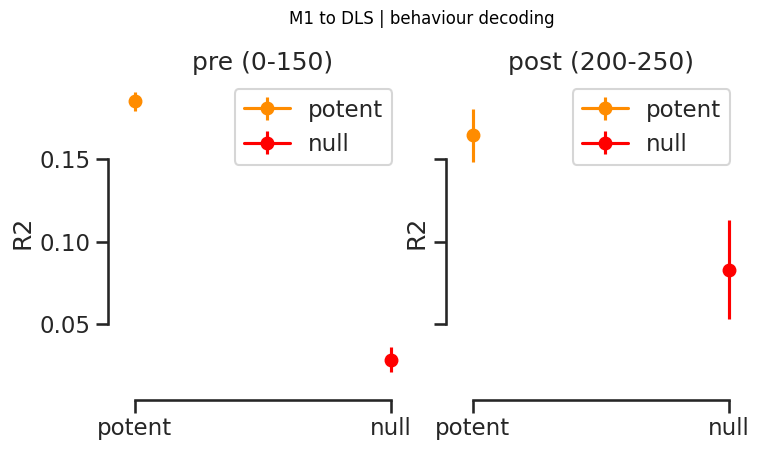

In [132]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
y = np.stack(td_potent_null_dropped.bhv.values)

win_specs = [("pre (0-150)", (0, 150)), ("post (200-250)", (200, 250))]

with vizutils.apply_plot_style('talk'):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

    for ax, (win_label, window) in zip(axs, win_specs):
        X_potent = np.stack(td_potent_null_dropped.MOp_rates_pca_potent_CP_rates_pca.values)[:, window[0]:window[1], :]
        X_null   = np.stack(td_potent_null_dropped.MOp_rates_pca_null_CP_rates_pca.values)[:, window[0]:window[1], :]
        y_win    = y[:, window[0]:window[1], :]

        r2s_potent = cross_val_score(
            Ridge(0.1),
            X_potent.reshape(-1, X_potent.shape[-1]),
            y_win.reshape(-1, y_win.shape[-1]),
            cv=5, scoring=vw_r2_scorer
        )
        r2s_null = cross_val_score(
            Ridge(0.1),
            X_null.reshape(-1, X_null.shape[-1]),
            y_win.reshape(-1, y_win.shape[-1]),
            cv=5, scoring=vw_r2_scorer
        )

        print(f"[{win_label}] potent={r2s_potent.mean():.4f}  null={r2s_null.mean():.4f}")

        ax.errorbar(0, r2s_potent.mean(), yerr=r2s_potent.std(), fmt="-o", color="darkorange",
                    capsize=0, label="potent")
        ax.errorbar(1, r2s_null.mean(),   yerr=r2s_null.std(),   fmt="-o", color="red",
                    capsize=0, label="null")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["potent", "null"])
        ax.set_ylabel("R2")
        ax.set_title(win_label)
        ax.legend()

    # plt.tight_layout()
plt.suptitle("M1 to DLS | behaviour decoding" , y=1.05)
plt.show()




In [6]:
pc_dict

NameError: name 'pc_dict' is not defined

In [21]:
td_potent_null = perturb_td_shuff.copy()
rng = np.random.default_rng(seed=42)
CP_shuff = np.stack(td_potent_null.CP_rates_pca.values)

perm = rng.permutation(CP_shuff.shape[0])

CP_shuff = CP_shuff[perm]
td_potent_null['CP_rates_pca'] = [arr for arr in CP_shuff]
td_potent_null = subspaces.compute_potent_null_td(
    td_=td_potent_null,
    signal_x='MOp_rates_pca',
    signal_y='CP_rates_pca',
    origin_rank=30,
    target_rank=30,
    fit_rank=False,
    rank=8,
    n_iter=2,
    window=(200, 400)
)

Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = -0.0160. Optimal rank: 8
Using 2 iterations...
	Iter: 1. Prediction R2 = -0.0089
	Iter: 2. Prediction R2 = -0.0116
	Final Prediction R2 = -0.0098
Diagnostics:
	Total MOp_rates_pca var:         12480.15
	Fraction Potent (dim: 8) var:    0.136
	Fraction Null (dim: 6) var:      0.124
	Fraction Null init var:          0.489
	Fraction MOp_rates_pca var:      0.625


  drop_trials_sem_crosses_zero: by SEM: 227  |  by value: 423  |  kept: 226/424 (53.3%)
[pre (0-150)] potent=0.0845  null=0.0895
[post (200-250)] potent=0.0981  null=0.0690


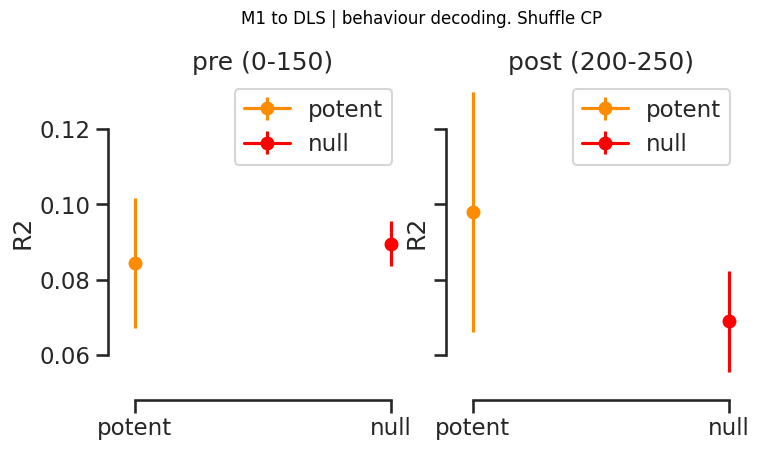

In [22]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=True)

y = np.stack(td_potent_null_dropped.bhv.values)

win_specs = [("pre (0-150)", (0, 150)), ("post (200-250)", (200, 250))]

with vizutils.apply_plot_style('talk'):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

    for ax, (win_label, window) in zip(axs, win_specs):
        X_potent = np.stack(td_potent_null_dropped.MOp_rates_pca_potent_CP_rates_pca.values)[:, window[0]:window[1], :]
        X_null   = np.stack(td_potent_null_dropped.MOp_rates_pca_null_CP_rates_pca.values)[:, window[0]:window[1], :]
        y_win    = y[:, window[0]:window[1], :]

        r2s_potent = cross_val_score(
            Ridge(0.1),
            X_potent.reshape(-1, X_potent.shape[-1]),
            y_win.reshape(-1, y_win.shape[-1]),
            cv=5, scoring=vw_r2_scorer
        )
        r2s_null = cross_val_score(
            Ridge(0.1),
            X_null.reshape(-1, X_null.shape[-1]),
            y_win.reshape(-1, y_win.shape[-1]),
            cv=5, scoring=vw_r2_scorer
        )

        print(f"[{win_label}] potent={r2s_potent.mean():.4f}  null={r2s_null.mean():.4f}")

        ax.errorbar(0, r2s_potent.mean(), yerr=r2s_potent.std(), fmt="-o", color="darkorange",
                    capsize=0, label="potent")
        ax.errorbar(1, r2s_null.mean(),   yerr=r2s_null.std(),   fmt="-o", color="red",
                    capsize=0, label="null")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["potent", "null"])
        ax.set_ylabel("R2")
        ax.set_title(win_label)
        ax.legend()

    # plt.tight_layout()
plt.suptitle("M1 to DLS | behaviour decoding. Shuffle CP" , y=1.05)
plt.show()




## Test in free

In [9]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td = pyal.load_pyaldata('/data/bnd-data/raw/' + sess[:4] + "/" + sess)
    td = dsp.preprocess(td, only_trials=False, combine_time_bins=False, std=0.03)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)


In [10]:
td = dt.add_pca_df(td.iloc[:1])

In [34]:
td = dt.add_bhv(td)

In [25]:
cp_free.shape

(48000, 267)

In [35]:
mop_free = np.stack(td.MOp_rates_pca.values[0])
cp_free = np.stack(td.CP_rates_pca.values[0])
bhv_free = np.stack(td.bhv.values[0])

In [41]:
r2, opt_rank = subspaces.cross_val_semedo_rrr(
        mop_free[:, :30], cp_free[:, :30], alpha=0.01, fit_rank=True, cv=KFold(5, shuffle=True)
    )

In [42]:
emb_pot = subspaces.compute_embedding_on_arrs(mop_free[:, :30], cp_free[:, :30], null=False, model=subspaces.ReducedRankCommSubspace(rank=opt_rank))
emb_null = subspaces.compute_embedding_on_arrs(mop_free[:, :30], cp_free[:, :30], null=True, model=subspaces.ReducedRankCommSubspace(rank=opt_rank))

In [43]:
mop_proj_cp = mop_free[:, :30] @ emb_pot
mop_proj_cp_null = mop_free[:, :30] @ emb_null

In [37]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")


In [44]:
r2s = cross_val_score(
    Ridge(0.01),
    mop_proj_cp,
    bhv_free,
    scoring=vw_r2_scorer,
    cv=KFold(5, shuffle=True)
)
r2s.mean(), r2s.std()


(0.47007163380019684, 0.004392375746600806)

In [45]:
r2s = cross_val_score(
    Ridge(0.01),
    mop_proj_cp_null,
    bhv_free,
    scoring=vw_r2_scorer,
    cv=KFold(5, shuffle=True)
)
r2s.mean(), r2s.std()


(0.0581141291684157, 0.0012337847133494435)